In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/gauravrawat99/test-data/test.csv
/kaggle/input/datasets/gauravrawat99/train-data/train.csv


In [1]:
pip install pandas numpy scikit-learn 

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
train=pd.read_csv("/kaggle/input/datasets/gauravrawat99/train-data/train.csv")
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [7]:
train.describe(include='all')

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Absence
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,347546
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,NaN
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,NaN
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,NaN
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,NaN
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,NaN
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,NaN


In [8]:
train.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [10]:
#Converting Heart disease col to 0/1 format
train['Heart Disease']=train['Heart Disease'].str.strip().str.lower()
train["Heart Disease"]=train['Heart Disease'].map({"presence": 1, "absence": 0})

AttributeError: Can only use .str accessor with string values!

In [11]:
#Check  after changing target col val
train.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,1
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,0
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,0
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,0
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,1


In [12]:
train.describe(include='all')

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873,0.448340
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007,0.497324
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000,0.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000,1.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


In [13]:
train['Heart Disease'].value_counts()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64

In [14]:
test=pd.read_csv("/kaggle/input/datasets/gauravrawat99/test-data/test.csv")
test

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,58,1,2,120,222,0,0,172,0,1.0,1,0,7
269996,899996,58,1,4,132,289,0,0,172,0,2.8,2,0,3
269997,899997,63,1,3,108,201,1,0,158,0,0.8,1,0,3
269998,899998,59,1,4,120,274,0,2,163,0,0.5,1,0,3


In [16]:
test.describe(include='all')

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.000000,270000.00000,270000.000000
mean,764999.500000,54.159870,0.716315,3.315107,130.555089,245.045270,0.080052,0.978493,152.783756,0.274656,0.718082,1.459356,0.45480,4.619774
std,77942.430678,8.255471,0.450787,0.851762,15.007908,33.695458,0.271374,0.998686,19.153454,0.446341,0.947417,0.546186,0.80127,1.950273
min,630000.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.00000,3.000000
25%,697499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.00000,3.000000
50%,764999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.00000,3.000000
75%,832499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.00000,7.000000
max,899999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.00000,7.000000


In [15]:
len_col_train = len(list(train.columns))
print("Train data col count: ", len_col_train)
print("Train data col names: ", list(train.columns))

len_col_test=len(list(test.columns))
print("Test data col count: ", len_col_test)
print("Test data col names: ", list(test.columns))

Train data col count:  15
Train data col names:  ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']
Test data col count:  14
Test data col names:  ['id', 'Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium']


In [20]:
#Feature engineering
train['age_group'] = pd.cut(train["Age"], bins=[0,30,40,50,60,70,100], labels=[0,1,2,3,4,5])

train['chol_level']=pd.cut(train['Cholesterol'], bins=[0,100, 200, 300, 400, 500, 600, 700], labels=[0,1,2,3,4,5,6])

train['bp_high']=(train["BP"] >= 140).astype(int)

train['heart_stress'] = train["Exercise angina"] * train['ST depression']

train['hr_ratio'] = train['Max HR'] / train['Age']

train['bp_chol_interaction'] = train['BP'] * train["Cholesterol"]

train['age_chol'] = train['Age'] * train['Cholesterol']

train['age_hr'] = train["Age"] * train['Max HR']

train['st_angina'] = train['ST depression'] * train['Exercise angina']

train['bp_age_ratio'] = train['BP'] / train['Age']

train['chol_age_ratio'] = train['Cholesterol'] / train['Age']

train['heart_workload'] = train['BP'] * train['Max HR']

train['chol_hr'] = train['Cholesterol'] * train['Max HR']

train['age_st'] = train['Age'] * train['ST depression']

In [21]:
train

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,...,hr_ratio,bp_chol_interaction,age_chol,age_hr,st_angina,bp_age_ratio,chol_age_ratio,heart_workload,chol_hr,age_st
0,0,58,1,4,152,239,0,0,158,1,...,2.724138,36328,13862,9164,3.6,2.620690,4.120690,24016,37762,208.8
1,1,52,1,1,125,325,0,2,171,0,...,3.288462,40625,16900,8892,0.0,2.403846,6.250000,21375,55575,0.0
2,2,56,0,2,160,188,0,2,151,0,...,2.696429,30080,10528,8456,0.0,2.857143,3.357143,24160,28388,0.0
3,3,44,0,3,134,229,0,2,150,0,...,3.409091,30686,10076,6600,0.0,3.045455,5.204545,20100,34350,44.0
4,4,58,1,4,140,234,0,2,125,1,...,2.155172,32760,13572,7250,3.8,2.413793,4.034483,17500,29250,220.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
629995,629995,56,0,1,110,226,0,0,132,0,...,2.357143,24860,12656,7392,0.0,1.964286,4.035714,14520,29832,0.0
629996,629996,54,1,4,128,249,1,2,150,0,...,2.777778,31872,13446,8100,0.0,2.370370,4.611111,19200,37350,0.0
629997,629997,67,1,4,130,275,0,0,149,0,...,2.223881,35750,18425,9983,0.0,1.940299,4.104478,19370,40975,0.0
629998,629998,52,1,4,140,199,0,2,157,0,...,3.019231,27860,10348,8164,0.0,2.692308,3.826923,21980,31243,0.0


In [23]:
#Data variables defining
X=train.drop(["id", "Heart Disease"], axis=1)
y=train['Heart Disease']

In [24]:
X.shape

(630000, 27)

In [69]:
!nvidia-smi

Fri Mar 13 06:24:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#Splitting for training and validation process
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

rfc=RandomForestClassifier(n_estimators=500, max_depth=10,  class_weight='balanced', random_state=42, n_jobs=-1).fit(X_train, y_train)

print("Training accutacy: ", rfc.score(X_train, y_train))
print("Validation accuracy: ", rfc.score(X_test, y_test))

Training accutacy:  0.8876772486772487
Validation accuracy:  0.8828095238095238


Feature Importance of Random Forest Classifier:  [5.48654850e-03 2.94673233e-02 1.74919696e-01 7.15566366e-04
 1.12522305e-03 4.69538565e-05 4.68390474e-03 5.85708550e-02
 7.20503172e-02 4.17712526e-02 6.19219946e-02 1.01850720e-01
 2.73810301e-01 1.20146830e-03 1.68776500e-04 1.19838364e-04
 2.74008582e-02 3.81188267e-02 1.10679730e-03 3.54426656e-03
 4.31100138e-03 2.85440917e-02 1.58245132e-03 1.16370959e-03
 1.23942536e-02 4.09431951e-03 4.98286850e-02]


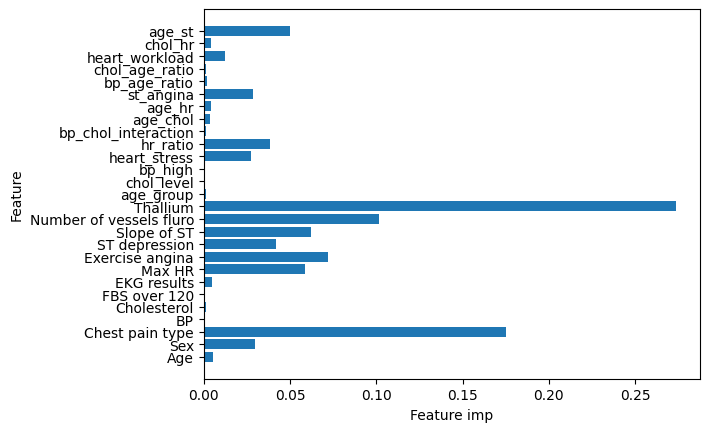

In [26]:
print("Feature Importance of Random Forest Classifier: ", rfc.feature_importances_)
def plot_feature_pruning(model):
    n_features=X.shape[1]
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), X.columns)
    plt.xlabel("Feature imp")
    plt.ylabel("Feature")
    # plt.title("After pre pruning")
plot_feature_pruning(rfc)

# XGBoost

In [72]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [81]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 29 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   id                       630000 non-null  int64   
 1   Age                      630000 non-null  int64   
 2   Sex                      630000 non-null  int64   
 3   Chest pain type          630000 non-null  int64   
 4   BP                       630000 non-null  int64   
 5   Cholesterol              630000 non-null  int64   
 6   FBS over 120             630000 non-null  int64   
 7   EKG results              630000 non-null  int64   
 8   Max HR                   630000 non-null  int64   
 9   Exercise angina          630000 non-null  int64   
 10  ST depression            630000 non-null  float64 
 11  Slope of ST              630000 non-null  int64   
 12  Number of vessels fluro  630000 non-null  int64   
 13  Thallium                 630000 non-null  in

In [80]:
from xgboost import XGBClassifier

#Encoding
X_encoded=pd.get_dummies(X, drop_first=True)
test_encoded=pd.get_dummies(test, drop_first=True)
test_encoded=test_encoded.reindex(columns=X_encoded.columns, fill_value=0)

xgbc=XGBClassifier(n_estimators=500, learning_rate=0.01, random_state=42, n_fold=-1, tree_method='hist', enable_categorical=True).fit(X_train, y_train)

print("Training accuracy: ", xgbc.score(X_train, y_train))
print("Validation accuracy: ", xgbc.score(X_test, y_test))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:54:28] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "n_fold" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training accuracy:  0.8878624338624339
Validation accuracy:  0.8847142857142857


### ROC_AUC

In [27]:
from sklearn.metrics import roc_auc_score, classification_report

#Random Forest Classifier AUC score
rfc_probs=rfc.predict_proba(X)[:, 1]
rfc_preds=(rfc_probs>0.5).astype(int)
rfc_auc=roc_auc_score(y, rfc_probs)

print("Random Forest Classifier ROC-AUC score: ", rfc_auc)
print("Classification report:\n", classification_report(y, rfc_preds) )

Random Forest Classifier ROC-AUC score:  0.9545719887196342
Classification report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90    347546
           1       0.87      0.88      0.87    282454

    accuracy                           0.89    630000
   macro avg       0.89      0.89      0.89    630000
weighted avg       0.89      0.89      0.89    630000



In [87]:
from sklearn.metrics import roc_auc_score, classification_report

#Random Forest Classifier AUC score
rfc_probs=rfc.predict_proba(X)[:, 1]
rfc_preds=(rfc_probs>0.5).astype(int)
rfc_auc=roc_auc_score(y, rfc_probs)

print("Random Forest Classifier ROC-AUC score: ", rfc_auc)
print("Classification report:\n", classification_report(y, rfc_preds) )

print("----------------------------------------------------------")

#XG Boost AUC score
xgbc_probs=xgbc.predict_proba(X)[:, 1]
xgbc_preds=(xgbc_probs>0.5).astype(int)
xgbc_auc=roc_auc_score(y, xgbc_probs)
print("XGBoost Classifier ROC-AUC score: ", xgbc_auc)
print("Classification Report:\n ", classification_report(y, xgbc_preds))

Random Forest Classifier ROC-AUC score:  0.9545719887196342
Classification report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90    347546
           1       0.87      0.88      0.87    282454

    accuracy                           0.89    630000
   macro avg       0.89      0.89      0.89    630000
weighted avg       0.89      0.89      0.89    630000

----------------------------------------------------------
XGBoost Classifier ROC-AUC score:  0.9545348422535078
Classification Report:
                precision    recall  f1-score   support

           0       0.89      0.91      0.90    347546
           1       0.88      0.87      0.87    282454

    accuracy                           0.89    630000
   macro avg       0.89      0.89      0.89    630000
weighted avg       0.89      0.89      0.89    630000



### Submission for Randomg Forest Classifier

In [37]:
test_ids=test['id']
test_ids

#Feature engineering
test['age_group'] = pd.cut(test["Age"], bins=[0,30,40,50,60,70,100], labels=[0,1,2,3,4,5])

test['chol_level']=pd.cut(test['Cholesterol'], bins=[0,100, 200, 300, 400, 500, 600, 700], labels=[0,1,2,3,4,5,6])

test['bp_high']=(test["BP"] >= 140).astype(int)

test['heart_stress'] = test["Exercise angina"] * test['ST depression']

test['hr_ratio'] = test['Max HR'] / test['Age']

test['bp_chol_interaction'] = test['BP'] * test["Cholesterol"]

test['age_chol'] = test['Age'] * test['Cholesterol']

test['age_hr'] = test["Age"] * test['Max HR']

test['st_angina'] = test['ST depression'] * test['Exercise angina']

test['bp_age_ratio'] = test['BP'] / test['Age']

test['chol_age_ratio'] = test['Cholesterol'] / test['Age']

test['heart_workload'] = test['BP'] * test['Max HR']

test['chol_hr'] = test['Cholesterol'] * test['Max HR']

test['age_st'] = test['Age'] * test['ST depression']

In [38]:
test

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,...,hr_ratio,bp_chol_interaction,age_chol,age_hr,st_angina,bp_age_ratio,chol_age_ratio,heart_workload,chol_hr,age_st
0,630000,58,1,3,120,288,0,2,145,1,...,2.500000,34560,16704,8410,0.8,2.068966,4.965517,17400,41760,46.4
1,630001,55,0,2,120,209,0,0,172,0,...,3.127273,25080,11495,9460,0.0,2.181818,3.800000,20640,35948,0.0
2,630002,54,1,4,120,268,0,0,150,1,...,2.777778,32160,14472,8100,0.0,2.222222,4.962963,18000,40200,0.0
3,630003,44,0,3,112,177,0,0,168,0,...,3.818182,19824,7788,7392,0.0,2.545455,4.022727,18816,29736,39.6
4,630004,43,1,1,138,267,0,0,163,0,...,3.790698,36846,11481,7009,0.0,3.209302,6.209302,22494,43521,77.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
269995,899995,58,1,2,120,222,0,0,172,0,...,2.965517,26640,12876,9976,0.0,2.068966,3.827586,20640,38184,58.0
269996,899996,58,1,4,132,289,0,0,172,0,...,2.965517,38148,16762,9976,0.0,2.275862,4.982759,22704,49708,162.4
269997,899997,63,1,3,108,201,1,0,158,0,...,2.507937,21708,12663,9954,0.0,1.714286,3.190476,17064,31758,50.4
269998,899998,59,1,4,120,274,0,2,163,0,...,2.762712,32880,16166,9617,0.0,2.033898,4.644068,19560,44662,29.5


In [40]:
import pandas as pd

# ------------------------
# REQUIRED inputs:
# ------------------------
id_col = "id"             
target_name = "Heart Disease"      

# Ensure test columns match training
# (Only needed if you transformed train earlier)
test_aligned = test[X.columns]    # X is your training feature matrix

# Predict probabilities
test_probs = rfc.predict_proba(test_aligned)[:, 1]

# Build submission DataFrame
submission = pd.DataFrame({
    id_col: test[id_col],
    target_name: test_probs
})

# Save
submission.to_csv("submission.csv", index=False)

# Summary output (like the one in your screenshot)
print("submission.csv saved!")
print(f"Shape             : {submission.shape}")
print(f"Mean prediction   : {submission[target_name].mean():.5f}")
print(f"Std  prediction   : {submission[target_name].std():.5f}")

display(submission.head(20))
print(submission.isnull().sum())

submission.csv saved!
Shape             : (270000, 2)
Mean prediction   : 0.46896
Std  prediction   : 0.38019


,id,Heart Disease
0,630000,0.790578
1,630001,0.016668
2,630002,0.965207
3,630003,0.012565
4,630004,0.398914
5,630005,0.985145
6,630006,0.046263
7,630007,0.677395
8,630008,0.990715
9,630009,0.020245


id               0
Heart Disease    0
dtype: int64
